In [1]:
import pandas as pd
import numpy as np
import openpyxl
import scipy as sp
import scipy.signal
import scipy.fftpack
import libs.append_path
from add_python_libraries import *
import pd_filter_fcns

#from ihlp_0v1 import Inductor_pdis, circuit_params, ind_pdis_obj, l_set, ihlp_filename
from cyntec import Inductor_pdis
# from circuit_4state import circuit_params as circuit_params_4state
# from circuit_2state import circuit_params as circuit_params_2state

from current_carova_MR_waveforms import Current_carova_MR_waveforms



### Input Parameters

In [2]:
input_params = {'vin' : 20,
                'vout': 11,
                'pin' : 100, 
                'eff' : .97, 
                'fs'  :175e3,
                'ton_mult':1,
                'tambient':25,
                'lout':{'family'   :'cmlb104t',
                        'value(uH)':1,
                        'config'   :'single'},
                'lvl_config':'3 level carova',
                'ddiv':2
               }
input_params['iout'] = input_params['pin']*input_params['eff']/input_params['vout']

### Individual inductor

In [3]:
lobj = Inductor_pdis(input_params) #ckt_params)

In [4]:
lobj.summary

{'dcr': 0.25777334622169323,
 'core': 0.5484528580552007,
 'ipp': 7.0713,
 'fs_dcm': 350000.0,
 'ton_mult': 1,
 'irms_dcm': 9.046314847924148}

In [5]:
lobj.losses()

Total: 0.806
DC: 0.258
core: 0.548
Temp: 52.3


In [6]:
lobj.ckt['Idc']

8.818181818181818

In [7]:
# class Current_carova_MR_waveforms:
#     def __init__(self, ind_obj):
#         self.lobj = ind_obj
#         self.fs = self.lobj.ckt['ip']['fs']
#         self.ts = 1/self.fs
#         self.tarray = np.linspace(0,self.ts/2,512)
#         self.ind_wf_dcmpulse = self.create_ind_waveform_dcmpulse(self.tarray)
#         self.i_ind = self.create_ind_waveform_2cycle_ccm()
#         self.i_hs = self.create_hs_waveform()
#         self.i_zin_ac = self.i_hs-np.mean(self.i_hs)
        
#     def create_ind_waveform_dcmpulse(self,t):
#         tstate = self.lobj.ckt['t_state']; deltaV = self.lobj.ckt['deltaV']; lout = self.lobj.ckt['ip']['lout']['value(uH)']*1e-6
#         tstart = {1:0, 2:tstate[1], 3:tstate[1]+tstate[2]}      
#         tend = {state:tstart[state]+tstate[state] for state in tstate.keys()}
#         ipp = {state:round(dv*tstate[state]/lout,3) for state,dv in deltaV.items()}   
#         i_start = {1:0, 2:ipp[1], 3:ipp[1]+ipp[2]}
#         def waveform(t):
#             def conditions(t):
#                 return [t < tend[1], (t>=tend[1]) & (t<tend[2]), t>=tend[2]]           
#             def functions():
#                 return [lambda x:i_start[1]+deltaV[1]*(x-tstart[1])/lout, 
#                         lambda x:i_start[2]+deltaV[2]*(x-tstart[2])/lout, 
#                         lambda x:i_start[3]+deltaV[3]*(x-tstart[3])/lout]
#             return np.piecewise(t,conditions(t),functions())
#         return waveform(t)   
#     def create_ind_waveform_2cycle_ccm(self):
#         t_2ndperiod = self.tarray+self.ts/2
#         self.time_datapoints = np.concatenate((self.tarray,t_2ndperiod))
#         wf_2cycles = np.concatenate((self.ind_wf_dcmpulse,self.ind_wf_dcmpulse))
#         avg = float(round(self.ind_wf_dcmpulse.mean(),3))
#         return wf_2cycles-avg+self.lobj.ckt['Idc']

#     def create_hs_waveform(self):
#         tstate = self.lobj.ckt['t_state']
#         d_hs_1stcycle = tstate[1]+tstate[2]
#         D_pulse_1stcycle = sp.signal.square(2*np.pi*self.tarray,d_hs_1stcycle)/2+0.5
#         d_hs_2ndcycle = tstate[1]
#         D_pulse_2ndcycle = sp.signal.square(2*np.pi*self.tarray,d_hs_2ndcycle)/2+0.5
#         D_pulse_2cycles = np.concatenate((D_pulse_1stcycle,D_pulse_2ndcycle))
#         return D_pulse_2cycles*self.i_ind


In [8]:
wfobj = Current_carova_MR_waveforms(lobj)

In [9]:
vin = wfobj.lobj.ckt['ip']['vin']
vout = wfobj.lobj.ckt['ip']['vout']

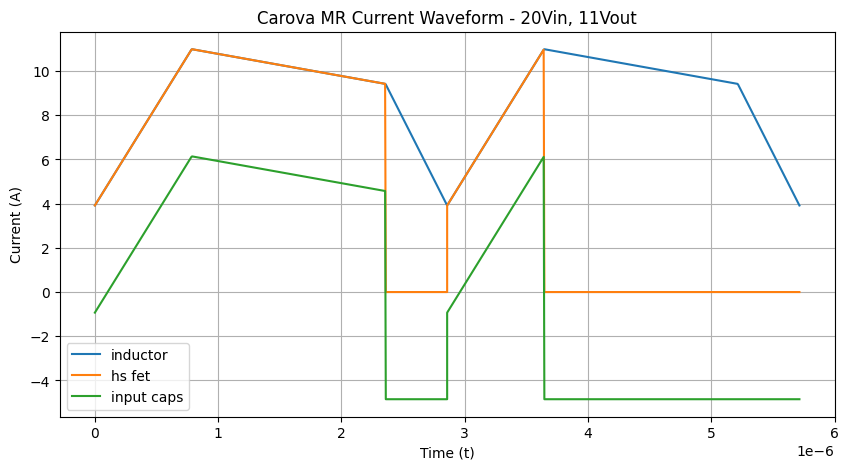

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(wfobj.time_datapoints, wfobj.i_ind, label='inductor')
plt.plot(wfobj.time_datapoints, wfobj.i_hs, label='hs fet')
plt.plot(wfobj.time_datapoints, wfobj.i_zin_ac, label='input caps')
plt.title(f'Carova MR Current Waveform - {vin}Vin, {vout}Vout'); plt.xlabel('Time (t)'); plt.ylabel('Current (A)')
plt.legend(); plt.grid(True)
plt.show()